In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [ ]:
df = pd.read_csv('gym.csv')
df

,Member_ID,Age,Gender,Membership_Type,Monthly_Fee,Attendance_Frequency,Trainer_Assigned,Diet_Plan,Avg_Workout_Duration,Weight_Loss,Complaints_Last_Month,App_Usage,Distance_From_Gym,Payment_Delay,Referral_Count,Churn,Monthly_Extra_Spending
0,1,58,Male,Basic,1000,4,Yes,Yes,37,7.4,5,7.4,8.4,9,3,Yes,2547
1,2,31,Male,VIP,3500,0,Yes,No,48,4.5,2,8.1,0.6,2,5,No,2942
2,3,27,Male,Premium,2000,1,Yes,No,32,3.6,2,6.0,12.2,7,4,Yes,2572
3,4,42,Male,VIP,3500,4,No,Yes,28,0.5,1,7.7,14.8,3,0,No,3232
4,5,58,Female,Basic,1000,5,No,Yes,54,7.0,5,6.5,9.3,2,4,No,1683
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1996,41,Female,VIP,3500,5,No,No,33,2.2,2,6.5,11.1,7,2,Yes,2573
1996,1997,39,Female,Premium,2000,3,No,Yes,50,8.6,4,3.7,5.9,8,0,No,2445
1997,1998,55,Female,Premium,2000,4,No,No,84,1.0,3,4.0,2.8,8,2,No,1460
1998,1999,30,Female,Basic,1000,3,Yes,No,76,0.0,0,4.7,4.1,9,3,No,1649


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Member_ID               2000 non-null   int64  
 1   Age                     2000 non-null   int64  
 2   Gender                  2000 non-null   object 
 3   Membership_Type         2000 non-null   object 
 4   Monthly_Fee             2000 non-null   int64  
 5   Attendance_Frequency    2000 non-null   int64  
 6   Trainer_Assigned        2000 non-null   object 
 7   Diet_Plan               2000 non-null   object 
 8   Avg_Workout_Duration    2000 non-null   int64  
 9   Weight_Loss             2000 non-null   float64
 10  Complaints_Last_Month   2000 non-null   int64  
 11  App_Usage               2000 non-null   float64
 12  Distance_From_Gym       2000 non-null   float64
 13  Payment_Delay           2000 non-null   int64  
 14  Referral_Count          2000 non-null   

In [ ]:
df.isnull().sum()

,0
Member_ID,0
Age,0
Gender,0
Membership_Type,0
Monthly_Fee,0
Attendance_Frequency,0
Trainer_Assigned,0
Diet_Plan,0
Avg_Workout_Duration,0
Weight_Loss,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace = True)
df

,Member_ID,Age,Gender,Membership_Type,Monthly_Fee,Attendance_Frequency,Trainer_Assigned,Diet_Plan,Avg_Workout_Duration,Weight_Loss,Complaints_Last_Month,App_Usage,Distance_From_Gym,Payment_Delay,Referral_Count,Churn,Monthly_Extra_Spending
0,1,58,Male,Basic,1000,4,Yes,Yes,37,7.4,5,7.4,8.4,9,3,Yes,2547
1,2,31,Male,VIP,3500,0,Yes,No,48,4.5,2,8.1,0.6,2,5,No,2942
2,3,27,Male,Premium,2000,1,Yes,No,32,3.6,2,6.0,12.2,7,4,Yes,2572
3,4,42,Male,VIP,3500,4,No,Yes,28,0.5,1,7.7,14.8,3,0,No,3232
4,5,58,Female,Basic,1000,5,No,Yes,54,7.0,5,6.5,9.3,2,4,No,1683
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1996,41,Female,VIP,3500,5,No,No,33,2.2,2,6.5,11.1,7,2,Yes,2573
1996,1997,39,Female,Premium,2000,3,No,Yes,50,8.6,4,3.7,5.9,8,0,No,2445
1997,1998,55,Female,Premium,2000,4,No,No,84,1.0,3,4.0,2.8,8,2,No,1460
1998,1999,30,Female,Basic,1000,3,Yes,No,76,0.0,0,4.7,4.1,9,3,No,1649


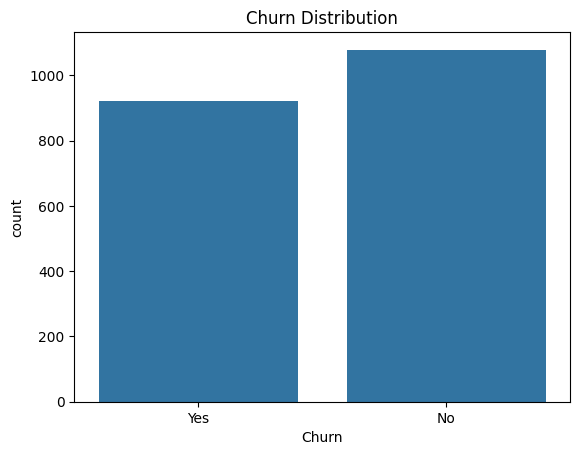

In [ ]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

<Axes: xlabel='Churn', ylabel='Age'>

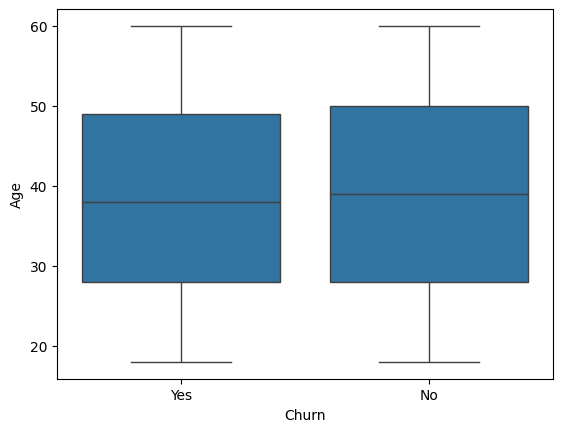

In [ ]:
sns.boxplot(x='Churn',y='Age', data=df)

<Axes: xlabel='Age', ylabel='Count'>

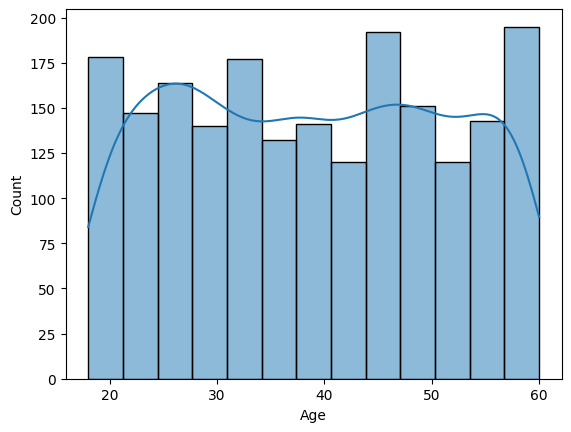

In [ ]:
sns.histplot(df['Age'], kde=True)

In [ ]:
df = pd.get_dummies(df,drop_first = True)
df

,Member_ID,Age,Monthly_Fee,Attendance_Frequency,Avg_Workout_Duration,Weight_Loss,Complaints_Last_Month,App_Usage,Distance_From_Gym,Payment_Delay,Referral_Count,Monthly_Extra_Spending,Gender_Male,Membership_Type_Premium,Membership_Type_VIP,Trainer_Assigned_Yes,Diet_Plan_Yes,Churn_Yes
0,1,58,1000,4,37,7.4,5,7.4,8.4,9,3,2547,True,False,False,True,True,True
1,2,31,3500,0,48,4.5,2,8.1,0.6,2,5,2942,True,False,True,True,False,False
2,3,27,2000,1,32,3.6,2,6.0,12.2,7,4,2572,True,True,False,True,False,True
3,4,42,3500,4,28,0.5,1,7.7,14.8,3,0,3232,True,False,True,False,True,False
4,5,58,1000,5,54,7.0,5,6.5,9.3,2,4,1683,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1996,41,3500,5,33,2.2,2,6.5,11.1,7,2,2573,False,False,True,False,False,True
1996,1997,39,2000,3,50,8.6,4,3.7,5.9,8,0,2445,False,True,False,False,True,False
1997,1998,55,2000,4,84,1.0,3,4.0,2.8,8,2,1460,False,True,False,False,False,False
1998,1999,30,1000,3,76,0.0,0,4.7,4.1,9,3,1649,False,False,False,True,False,False


In [ ]:
#logistic regression
X = df.drop("Churn_Yes", axis=1)
Y = df["Churn_Yes"]
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.2, random_state = 2)
lr = LogisticRegression()
lr.fit(X_train, Y_train)
lr_pred = lr.predict(X_test)
# Training Score
training_score = lr.score(X_train, Y_train)
print("Training Score is:", training_score)

# Prediction
y_pred = lr.predict(X_test)

# Accuracy
accuracy = accuracy_score(Y_test, y_pred)
print("Accuracy score is:", accuracy)

# Confusion Matrix
cm = confusion_matrix(Y_test, y_pred)
print("Confusion Matrix is:\n", cm)

# Classification Report
cr = classification_report(Y_test, y_pred)
print("Classification Report is:\n", cr)


Training Score is: 0.676875
Accuracy score is: 0.6825
Confusion Matrix is:
 [[155  57]
 [ 70 118]]
Classification Report is:
               precision    recall  f1-score   support

       False       0.69      0.73      0.71       212
        True       0.67      0.63      0.65       188

    accuracy                           0.68       400
   macro avg       0.68      0.68      0.68       400
weighted avg       0.68      0.68      0.68       400



/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix

# Create the model
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42)

# Train the model
dt_gini.fit(X_train, Y_train)

# Make predictions
dt_pred = dt_gini.predict(X_test)

# Calculate accuracy
accuracy_gini = accuracy_score(Y_test, dt_pred)
print("Accuracy Score using Gini Impurity:", accuracy_gini)

# Confusion matrix
cm1 = confusion_matrix(Y_test, dt_pred)
print(cm1)

Accuracy Score using Gini Impurity: 0.65
[[149  63]
 [ 77 111]]


In [ ]:
#random forest
rf = RandomForestClassifier(random_state = 42)
rf.fit(X_train,Y_train)
rf_pred = rf.predict(X_test)
accuracy_rf = accuracy_score(Y_test, rf_pred)
print("Accuracy Score in Random Forest is:",accuracy_rf)
cm2 = confusion_matrix(Y_test, y_pred)
print("Confusion Matrix is:\n", cm2)
cr2 = classification_report(Y_test, y_pred)
print("Classification Report is:\n", cr2)


Accuracy Score in Random Forest is: 0.7225
Confusion Matrix is:
 [[155  57]
 [ 70 118]]
Classification Report is:
               precision    recall  f1-score   support

       False       0.69      0.73      0.71       212
        True       0.67      0.63      0.65       188

    accuracy                           0.68       400
   macro avg       0.68      0.68      0.68       400
weighted avg       0.68      0.68      0.68       400



In [ ]:
#KNN
model_knn = KNeighborsClassifier(n_neighbors=3)
model_knn.fit(X_train, Y_train)
print("Training Score for KNN :",model_knn.score(X_train,Y_train))
y_pred_knn =model_knn.predict(X_test)
accuracy_knn = accuracy_score(Y_test, y_pred_knn)
print("Accuracy Score for KNN :",accuracy_knn)
cm3 = confusion_matrix(Y_test,y_pred_knn)
print("Confusion Matrix for KNN :\n",cm3)
cr3 = classification_report(Y_test,y_pred_knn)
print("Classification Report for KNN :\n",cr3)

Training Score for KNN : 0.7575
Accuracy Score for KNN : 0.5075
Confusion Matrix for KNN :
 [[114  98]
 [ 99  89]]
Classification Report for KNN :
               precision    recall  f1-score   support

       False       0.54      0.54      0.54       212
        True       0.48      0.47      0.47       188

    accuracy                           0.51       400
   macro avg       0.51      0.51      0.51       400
weighted avg       0.51      0.51      0.51       400



In [ ]:

from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, confusion_matrix

# Create SVM model with feature scaling
svm_model = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', random_state=42)
)

# Train the model
svm_model.fit(X_train, Y_train)

# Predict
svm_pred = svm_model.predict(X_test)

# Evaluate
print("SVM Accuracy:", accuracy_score(Y_test, svm_pred))
print("Confusion Matrix:")
print(confusion_matrix(Y_test, svm_pred))


SVM Accuracy: 0.0
Confusion Matrix:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [ ]:
#linear regression
X = df.drop("Monthly_Extra_Spending", axis=1)
Y = df["Monthly_Extra_Spending"]
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.2, random_state = 2)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
lr = LinearRegression()
lr.fit(X_train, Y_train)
training_score= lr.score(X_train,Y_train)
print("Training score is:",training_score)
lr_pred = lr.predict(X_test)
mse = mean_squared_error(Y_test, lr_pred)
print("Mean Squared Error is:", mse)
rmse = np.sqrt(mse)
print("Root Mean Squared Error is:", rmse)
mae = mean_absolute_error(Y_test, lr_pred)
print("Mean Absolute Error is:", mae)
r2 = r2_score(Y_test, lr_pred)
print("Performance as per R-Square is:", r2)
n = len(Y_test)
p = X_test.shape[1]

Training score is: 0.9751587128886678
Mean Squared Error is: 22766.49476991872
Root Mean Squared Error is: 150.8857010121195
Mean Absolute Error is: 130.73356113745086
Performance as per R-Square is: 0.9722470527054238


In [ ]:
# Decision Tree Regressor
dt_gini = DecisionTreeRegressor(random_state=42)

# Train the model
dt_gini.fit(X_train, Y_train)

# Make predictions
y_pred_gini = dt_gini.predict(X_test)

# Training Score
training_score = dt_gini.score(X_train, Y_train)
print("Training Score:", training_score)

# Mean Squared Error
mse = mean_squared_error(Y_test, y_pred_gini)
print("Mean Squared Error:", mse)

# Root Mean Squared Error
rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)

# Mean Absolute Error
mae = mean_absolute_error(Y_test, y_pred_gini)
print("Mean Absolute Error:", mae)

# R-Square
r2 = r2_score(Y_test, y_pred_gini)
print("R-Square value:", r2)

# Adjusted R-Square
n = len(Y_test)
p = X_test.shape[1]

if n > p + 1:
    adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
    print("Adjusted R-Square:", adjusted_r2)
else:
    print("Adjusted R-Square cannot be calculated reliably: test samples must exceed the number of features plus one.")

Training Score: 1.0
Mean Squared Error: 49685.9475
Root Mean Squared Error: 222.90344882930816
Mean Absolute Error: 181.7375
R-Square value: 0.9394315420013379
Adjusted R-Square: 0.9367360870642247


In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state = 42)
rf.fit(X_train,Y_train)
rf_training_score = rf.score(X_train,Y_train)
print("Training Score in RF:",rf_training_score)
rf_pred = rf.predict(X_test)
r2_score_rf = r2_score(Y_test, rf_pred)
print("R2 Score of Random Forest:",r2_score_rf)

Training Score in RF: 0.9958130254098889
R2 Score of Random Forest: 0.96575775817219
